# 🔬 Notebook 03 — Aprendizaje No Supervisado
## PCA + K-Means · NHANES 2015-2016 · Autor: Álvaro

**Objetivo:** Descubrir **fenotipos o perfiles metabólicos** ocultos en la población adulta de NHANES 2015-2016, utilizando técnicas de aprendizaje no supervisado.

### ¿Por qué No Supervisado?
A diferencia de la clasificación supervisada (Notebook 04), aquí **no usamos la etiqueta** `IS_LONGEVO`.  
El propósito es que el algoritmo encuentre agrupaciones naturales basándose exclusivamente en los biomarcadores de salud. Esto nos permite:
- Identificar perfiles de riesgo que el negocio no había definido a priori.
- Validar si los clusters descubiertos coinciden con la longevidad real.
- Generar "segmentos de pacientes" útiles para la app de Edad Biológica.

### Pipeline:
1. PCA (Análisis de Componentes Principales) → Reducción de dimensionalidad
2. K-Means → Agrupamiento en K clusters
3. Validación: Método del Codo + Silhouette Score
4. Interpretación de centroides → Perfiles de salud

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
})

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

Usamos el dataset generado en el Notebook 02, que ya está:
- Libre de nulos (imputación con KNNImputer y SimpleImputer)
- Con variables categóricas codificadas (One-Hot Encoding)
- Con variables numéricas escaladas (StandardScaler)

> **Importante:** PCA y K-Means son sensibles a la escala de las variables, por eso es indispensable usar datos escalados.

In [2]:
# Cargar datos procesados
DATA_PATH = '../data/02_intermediate/nhanes_2015_procesado.csv'
META_PATH = '../data/02_intermediate/metadata_preprocesamiento.json'

df = pd.read_csv(DATA_PATH)

# Cargar metadatos (con fallback si el JSON no existe o está corrupto)
try:
    with open(META_PATH, 'r') as f:
        meta = json.load(f)
    print('📝 Metadatos cargados desde JSON.')
except (FileNotFoundError, json.JSONDecodeError):
    print('⚠️ JSON de metadatos no disponible. Derivando info del CSV...')
    cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
    meta = {
        'todas_las_features': [c for c in df.columns if c not in cols_excluir],
    }

print(f'📦 Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Nulos: {df.isnull().sum().sum()}')
print(f'   Features: {len(meta["todas_las_features"])}')
df.head(3)

📝 Metadatos cargados desde JSON.
📦 Dataset cargado: 5,992 filas × 40 columnas
   Nulos: 0
   Features: 37


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_4,DMDEDUC2_5,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,83732.0,62.0,-0.759124,-0.645543,1.271620,0.645349,1.865649,-0.221276,0.105828,1.270937,...,0,1,0,0,0,0,0,0,0,0
1,83733.0,53.0,-1.338647,-1.205973,-0.740449,0.438660,0.536694,0.211680,0.519393,-0.147657,...,0,0,0,0,1,0,0,0,0,0
2,83734.0,78.0,-0.759124,-0.645543,-0.615924,0.109837,0.404813,-0.076957,1.042430,-0.790039,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# ── Preparar la matriz de features (X) ─────────────────────────────────
# Excluimos SEQN (ID), RIDAGEYR (target de regresión) e IS_LONGEVO (target de clasificación)
# PCA se aplica SOLO sobre las features, no sobre las variables objetivo.

cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
feature_cols = [c for c in df.columns if c not in cols_excluir]

X = df[feature_cols].values
print(f'📐 Matriz de features X: {X.shape}')
print(f'   Columnas: {feature_cols}')

📐 Matriz de features X: (5992, 37)
   Columnas: ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS', 'LBXTC', 'LBXGLU', 'RIAGENDR_2', 'RIDRETH3_2', 'RIDRETH3_3', 'RIDRETH3_4', 'RIDRETH3_6', 'RIDRETH3_7', 'DMDEDUC2_2', 'DMDEDUC2_3', 'DMDEDUC2_4', 'DMDEDUC2_5', 'DMDEDUC2_9', 'DMDMARTL_2', 'DMDMARTL_3', 'DMDMARTL_4', 'DMDMARTL_5', 'DMDMARTL_6', 'DMDMARTL_77', 'DMDMARTL_99']


## 3. PCA — Análisis de Componentes Principales

### ¿Por qué PCA?
- **Reducción de dimensionalidad:** Con ~25+ features, la visualización directa es imposible. PCA nos permite proyectar los datos en 2-3 dimensiones conservando la mayor varianza posible.
- **Eliminación de ruido:** Los componentes menores (que explican poca varianza) suelen capturar ruido, no señal real.
- **Mejora de K-Means:** En espacios de alta dimensionalidad, las distancias euclidianas (que usa K-Means) se vuelven menos informativas ("maldición de la dimensionalidad"). PCA mitiga este efecto.

Primero, aplicamos PCA **completo** para ver cuánta varianza explica cada componente.

In [4]:
# ── PCA completo (todos los componentes) ───────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Tabla de varianza por componente
df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza Explicada (%)': (varianza_explicada * 100).round(2),
    'Varianza Acumulada (%)': (varianza_acumulada * 100).round(2)
})

print('📊 Varianza explicada por componente (primeros 10):')
df_varianza.head(10)

📊 Varianza explicada por componente (primeros 10):


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,23.19,23.19
1,PC2,16.09,39.29
2,PC3,11.63,50.92
3,PC4,10.59,61.51
4,PC5,7.68,69.19
5,PC6,4.77,73.96
6,PC7,4.53,78.50
7,PC8,4.11,82.60
8,PC9,3.88,86.48
9,PC10,1.69,88.17


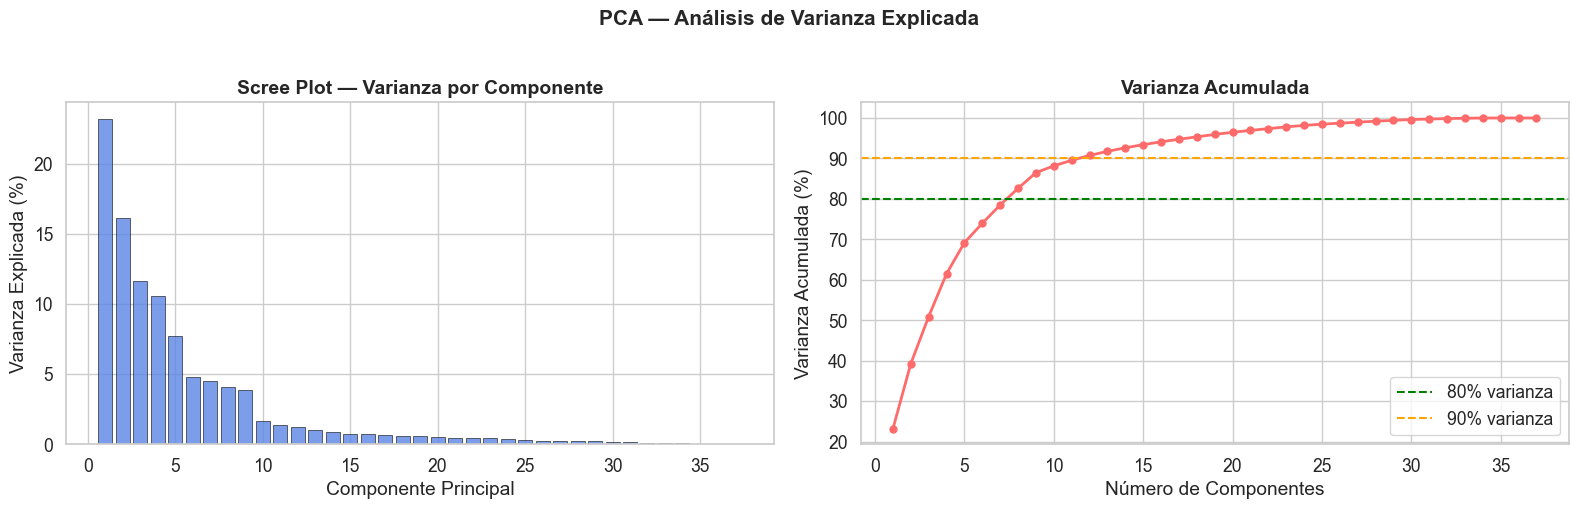


📈 Componentes para 80% de varianza: 8
📈 Componentes para 90% de varianza: 12


In [5]:
# ── Gráfico de varianza explicada (Scree Plot) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Varianza individual
axes[0].bar(range(1, len(varianza_explicada) + 1), varianza_explicada * 100,
            color='#5B86E5', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot — Varianza por Componente')

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100,
             'o-', color='#FF6B6B', linewidth=2, markersize=5)
axes[1].axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='80% varianza')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()

plt.suptitle('PCA — Análisis de Varianza Explicada', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ¿Cuántos componentes necesitamos para el 80% y 90%?
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f'\n📈 Componentes para 80% de varianza: {n_80}')
print(f'📈 Componentes para 90% de varianza: {n_90}')

### 3.1 Reducción a 2 componentes (para visualización)

Para poder graficar los clusters en un plano 2D, reducimos a **2 componentes principales**.  
Aunque perdemos información, los primeros 2 PCs capturan las direcciones de mayor varianza y permiten una interpretación visual inmediata.

In [6]:
# ── PCA con 2 componentes ──────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)

print(f'📐 Datos reducidos a 2D: {X_pca_2d.shape}')
print(f'   Varianza explicada PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'   Varianza explicada PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'   Varianza total (2 PCs): {sum(pca_2d.explained_variance_ratio_)*100:.1f}%')

# Crear DataFrame para facilitar los gráficos
df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['RIDAGEYR'] = df['RIDAGEYR'].values
df_pca['IS_LONGEVO'] = df['IS_LONGEVO'].values

📐 Datos reducidos a 2D: (5992, 2)
   Varianza explicada PC1: 23.2%
   Varianza explicada PC2: 16.1%
   Varianza total (2 PCs): 39.3%


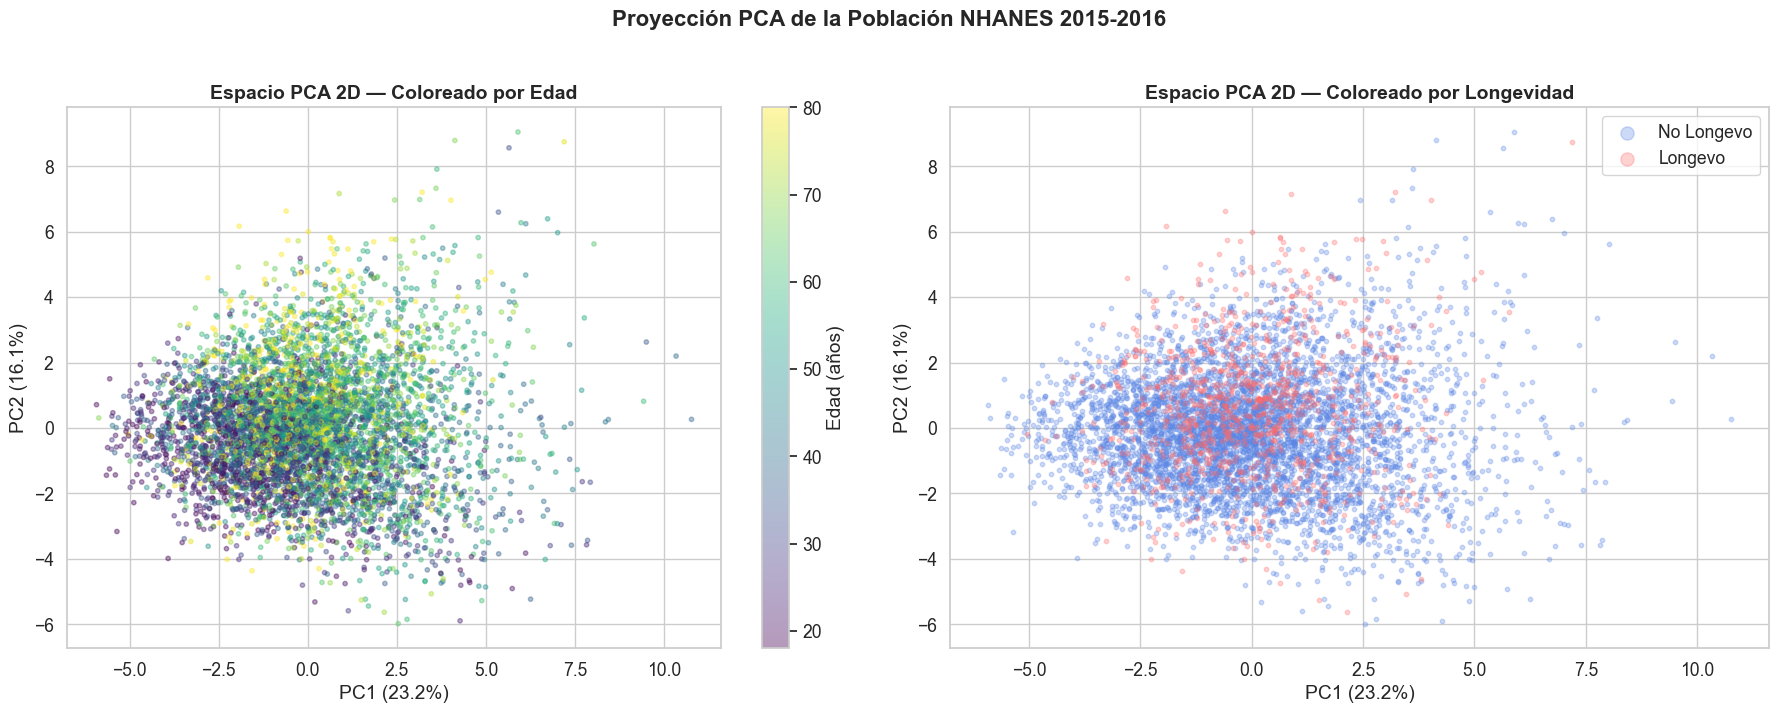

In [7]:
# ── Visualización de los datos en el espacio PCA 2D ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Coloreado por edad
scatter1 = axes[0].scatter(df_pca['PC1'], df_pca['PC2'],
                           c=df_pca['RIDAGEYR'], cmap='viridis',
                           alpha=0.4, s=10)
plt.colorbar(scatter1, ax=axes[0], label='Edad (años)')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Espacio PCA 2D — Coloreado por Edad')

# Coloreado por longevidad
for label, color, name in [(0, '#5B86E5', 'No Longevo'), (1, '#FF6B6B', 'Longevo')]:
    mask = df_pca['IS_LONGEVO'] == label
    axes[1].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    c=color, alpha=0.3, s=10, label=name)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Espacio PCA 2D — Coloreado por Longevidad')
axes[1].legend(markerscale=3)

plt.suptitle('Proyección PCA de la Población NHANES 2015-2016',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Interpretación de los componentes principales

¿Qué variables originales pesan más en cada componente? Los **loadings** (pesos) de PCA nos dicen qué variables contribuyen más a cada eje.

In [8]:
# ── Loadings (pesos de cada variable en los PCs) ───────────────────────
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

# Top contribuidores a PC1 y PC2
print('🔍 Top 8 variables con mayor peso en PC1 (valor absoluto):')
print(loadings['PC1'].abs().sort_values(ascending=False).head(8).round(3).to_string())
print(f'\n🔍 Top 8 variables con mayor peso en PC2:')
print(loadings['PC2'].abs().sort_values(ascending=False).head(8).round(3).to_string())

🔍 Top 8 variables con mayor peso en PC1 (valor absoluto):
BMXWT       0.353
BMXWAIST    0.330
BMXARMC     0.325
BMXBMI      0.300
BPXSY3      0.280
BPXSY2      0.277
BPXSY1      0.268
BPXDI1      0.266

🔍 Top 8 variables con mayor peso en PC2:
BPXSY1     0.325
BPXSY2     0.323
BPXSY3     0.322
BMXWT      0.314
BMXARMC    0.290
BPXDI2     0.264
BPXDI1     0.263
BPXDI3     0.257


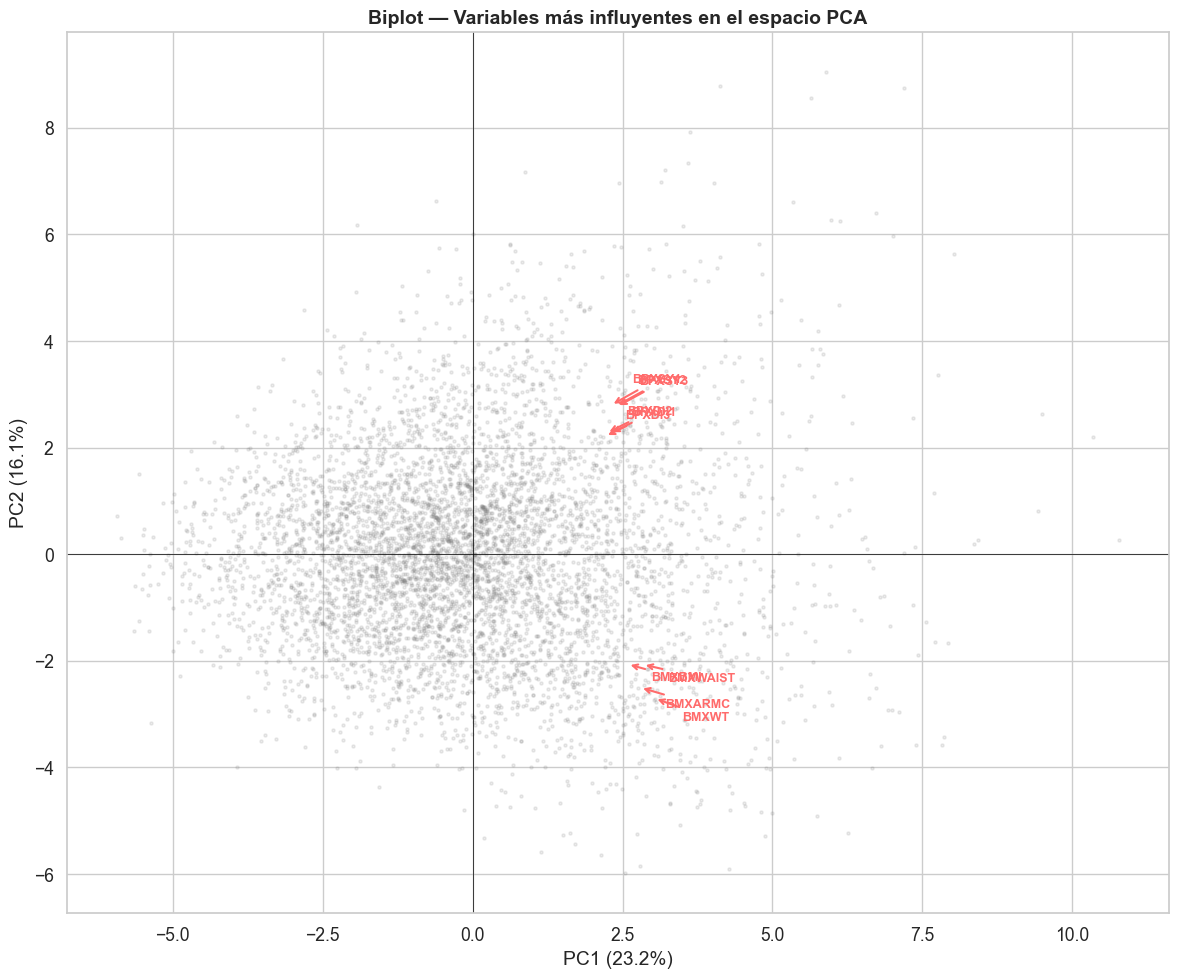

In [9]:
# ── Biplot: Flechas de los loadings sobre el scatter PCA ───────────────
fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.15, s=5, color='gray')

# Dibujar flechas para las variables más importantes
top_vars = loadings.apply(lambda x: x.abs()).sum(axis=1).sort_values(ascending=False).head(10).index

scale_factor = max(df_pca['PC1'].abs().max(), df_pca['PC2'].abs().max()) * 0.8
for var in top_vars:
    ax.annotate(
        var,
        xy=(loadings.loc[var, 'PC1'] * scale_factor,
            loadings.loc[var, 'PC2'] * scale_factor),
        fontsize=9, fontweight='bold', color='#FF6B6B',
        arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1.5),
        xytext=(loadings.loc[var, 'PC1'] * scale_factor * 1.15,
                loadings.loc[var, 'PC2'] * scale_factor * 1.15),
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot — Variables más influyentes en el espacio PCA', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 4. K-Means — Determinación del número óptimo de clusters

### ¿Por qué K-Means?
- Es el algoritmo de clustering más interpretable y eficiente para datos numéricos.
- Produce **centroides** que podemos interpretar directamente como "el paciente promedio" de cada grupo.
- Es escalable a nuestro dataset (~6,000+ filas).

### ¿Cómo elegimos K?
Usamos **dos métodos complementarios** para justificar la elección:
1. **Método del Codo (Elbow):** Busca el punto donde la reducción de inercia se desacelera.
2. **Silhouette Score:** Mide qué tan bien separados están los clusters (0 a 1, mayor = mejor).

In [10]:
# ── Evaluar K de 2 a 8 ─────────────────────────────────────────────────
K_range = range(2, 9)
inertias = []
silhouettes = []

print('⏳ Evaluando K-Means para K = 2..8...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_pca_2d)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca_2d, labels)
    silhouettes.append(sil)
    print(f'   K={k}: Inercia={km.inertia_:,.0f}, Silhouette={sil:.4f}')

print('\n✅ Evaluación completada.')

⏳ Evaluando K-Means para K = 2..8...
   K=2: Inercia=31,341, Silhouette=0.3466
   K=3: Inercia=21,976, Silhouette=0.3564
   K=4: Inercia=17,614, Silhouette=0.3171
   K=5: Inercia=14,550, Silhouette=0.3174
   K=6: Inercia=12,425, Silhouette=0.3314
   K=7: Inercia=10,962, Silhouette=0.3152
   K=8: Inercia=9,578, Silhouette=0.3291

✅ Evaluación completada.


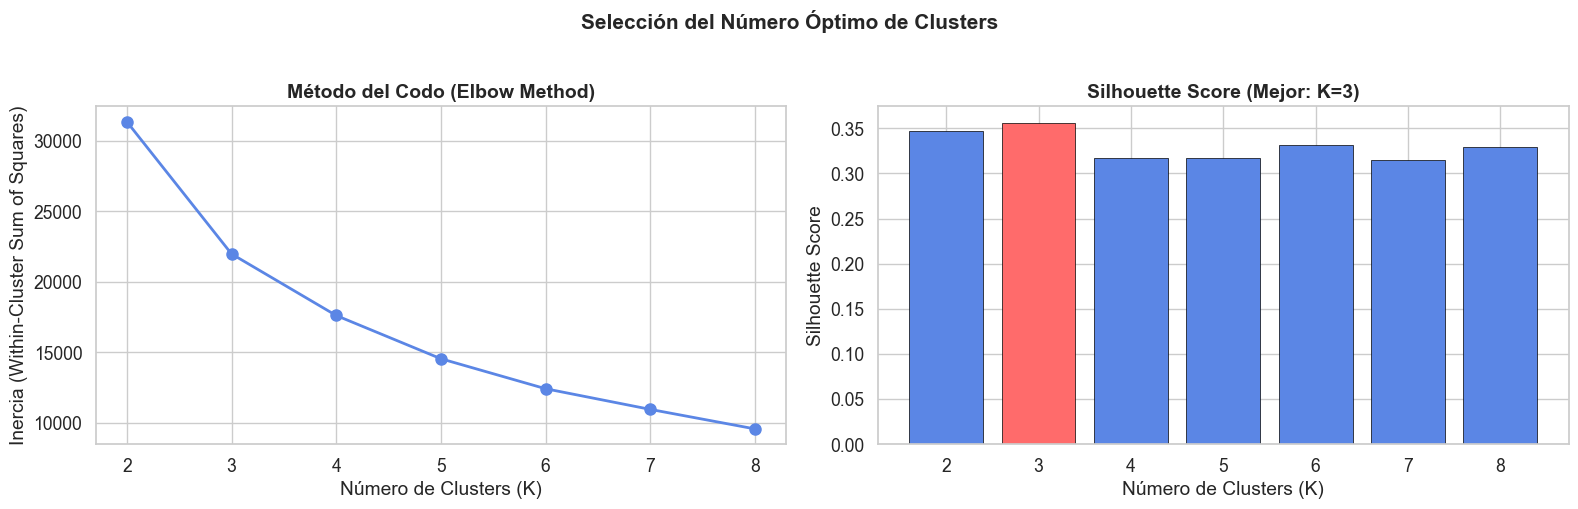


🏆 Mejor K según Silhouette Score: K=3 (score=0.3564)


In [11]:
# ── Gráficos de Codo y Silhouette ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Método del Codo
axes[0].plot(list(K_range), inertias, 'o-', color='#5B86E5', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (Within-Cluster Sum of Squares)')
axes[0].set_title('Método del Codo (Elbow Method)')
axes[0].set_xticks(list(K_range))

# Silhouette Score
best_k_idx = np.argmax(silhouettes)
best_k = list(K_range)[best_k_idx]
colors_sil = ['#FF6B6B' if i == best_k_idx else '#5B86E5' for i in range(len(K_range))]
axes[1].bar(list(K_range), silhouettes, color=colors_sil, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title(f'Silhouette Score (Mejor: K={best_k})')
axes[1].set_xticks(list(K_range))

plt.suptitle('Selección del Número Óptimo de Clusters',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n🏆 Mejor K según Silhouette Score: K={best_k} (score={silhouettes[best_k_idx]:.4f})')

### 4.1 Decisión: Número de clusters

Seleccionamos **K=4** como valor de trabajo (ajustable según los resultados del codo y silhouette).  
La lógica de negocio sugiere que 3-4 perfiles tienen sentido clínico:
- Grupo sano / bajo riesgo
- Grupo riesgo metabólico moderado
- Grupo riesgo alto (obesidad/hipertensión)
- Grupo longevo / frágil

> **Nota:** Si el Silhouette Score indicó un K diferente, se puede ajustar la celda siguiente.

In [12]:
# ── K-Means final ──────────────────────────────────────────────────────
# Usamos K=4 como valor por defecto, pero puedes cambiarlo según los gráficos.
# Si el Silhouette Score sugiere otro K, modifica esta variable:
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10, max_iter=300)
df_pca['CLUSTER'] = kmeans_final.fit_predict(X_pca_2d)

print(f'✅ K-Means entrenado con K={K_FINAL}')
print(f'   Silhouette Score: {silhouette_score(X_pca_2d, df_pca["CLUSTER"]):.4f}')
print(f'\n📊 Distribución de pacientes por cluster:')
print(df_pca['CLUSTER'].value_counts().sort_index().to_string())

✅ K-Means entrenado con K=4
   Silhouette Score: 0.3171

📊 Distribución de pacientes por cluster:
CLUSTER
0    1586
1    1366
2     955
3    2085


## 5. Visualización de los clusters

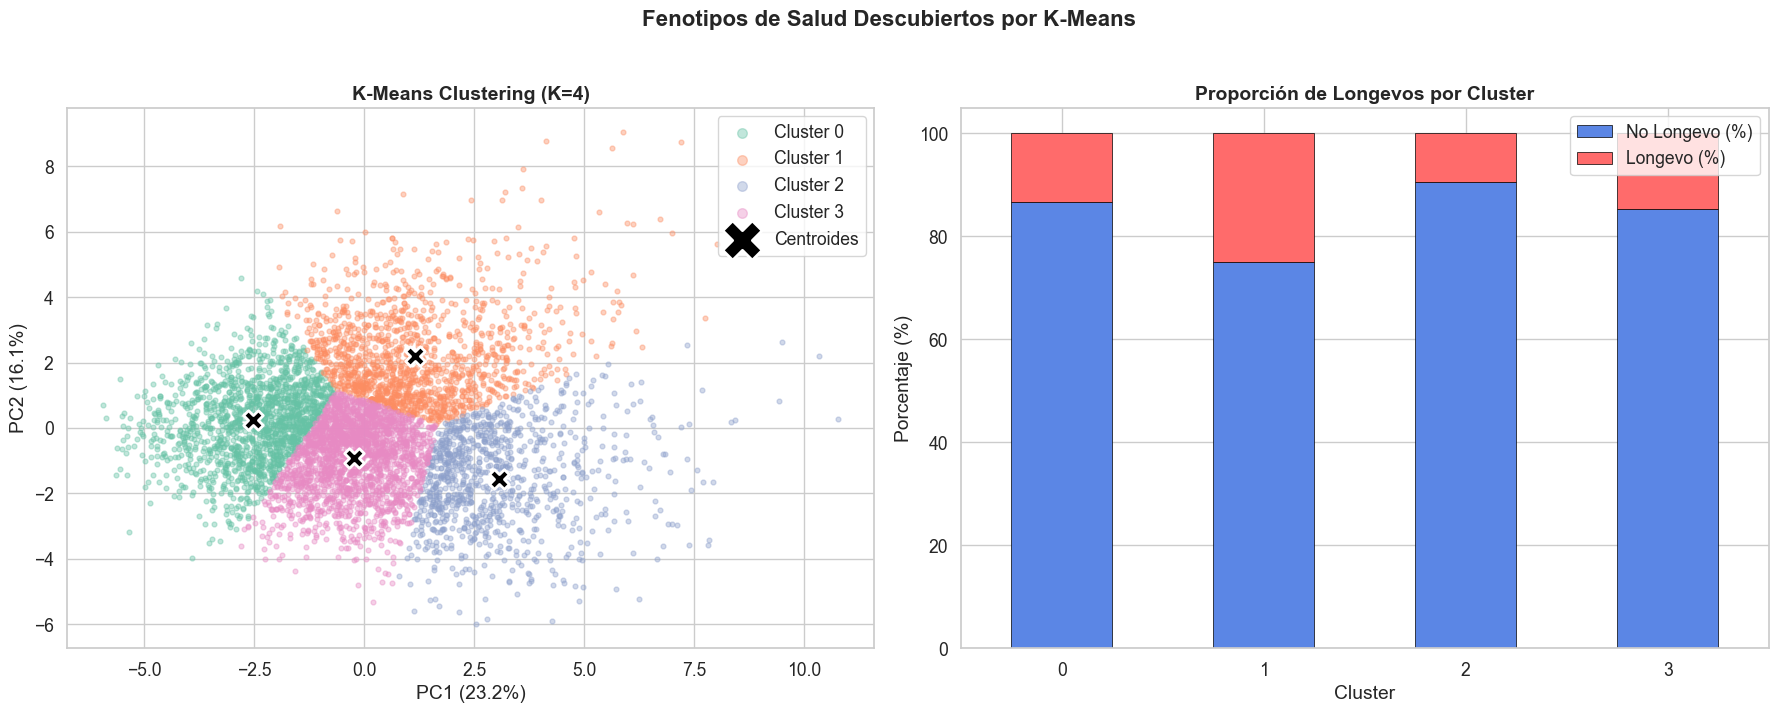

In [13]:
# ── Scatter plot 2D de los clusters ────────────────────────────────────
palette_clusters = sns.color_palette('Set2', n_colors=K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Clusters con centroides
for cluster_id in range(K_FINAL):
    mask = df_pca['CLUSTER'] == cluster_id
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    c=[palette_clusters[cluster_id]], alpha=0.4, s=12,
                    label=f'Cluster {cluster_id}')

# Centroides
centroids_pca = kmeans_final.cluster_centers_
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, edgecolors='white', linewidths=2,
                label='Centroides', zorder=5)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'K-Means Clustering (K={K_FINAL})')
axes[0].legend(markerscale=2)

# Clusters vs Longevidad (crosstab)
ct = pd.crosstab(df_pca['CLUSTER'], df_pca['IS_LONGEVO'], normalize='index') * 100
ct.columns = ['No Longevo (%)', 'Longevo (%)']
ct.plot(kind='bar', stacked=True, color=['#5B86E5', '#FF6B6B'],
        ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title('Proporción de Longevos por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='', loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Fenotipos de Salud Descubiertos por K-Means',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Interpretación de centroides — Perfiles de Salud

Para darle significado clínico a cada cluster, analizamos los **valores promedio de los biomarcadores originales** (sin escalar) dentro de cada grupo. Esto nos permite interpretar cada cluster como un "fenotipo de salud".

In [14]:
# ── Agregar el cluster al dataframe original ───────────────────────────
df['CLUSTER'] = df_pca['CLUSTER'].values

# Variables clave para interpretación (nombres originales)
vars_interpretacion = ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT',
                       'BPXSY1', 'BPXDI1', 'BPXPLS', 'LBXTC', 'LBXGLU',
                       'INDFMPIR', 'DMDHHSIZ']
# Usamos las que existan en el dataset
vars_interp_exist = [v for v in vars_interpretacion if v in df.columns]

# Tabla de perfiles por cluster
perfil_clusters = df.groupby('CLUSTER')[vars_interp_exist].mean().round(2)
perfil_clusters.index = [f'Cluster {i}' for i in perfil_clusters.index]

print('📊 Perfil Promedio de cada Cluster (valores escalados excepto RIDAGEYR):')
perfil_clusters.T

📊 Perfil Promedio de cada Cluster (valores escalados excepto RIDAGEYR):


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
RIDAGEYR,42.44,57.49,47.17,46.74
BMXBMI,-0.76,-0.20,1.37,0.08
BMXWAIST,-0.88,-0.15,1.42,0.11
BMXWT,-0.91,-0.30,1.64,0.14
BMXHT,-0.56,-0.24,0.76,0.24
BPXSY1,-0.64,1.08,0.26,-0.34
BPXDI1,-0.57,0.83,0.43,-0.31
BPXPLS,-0.07,-0.00,0.30,-0.08
LBXTC,-0.13,0.31,0.02,-0.11
LBXGLU,-0.34,0.03,0.59,-0.03


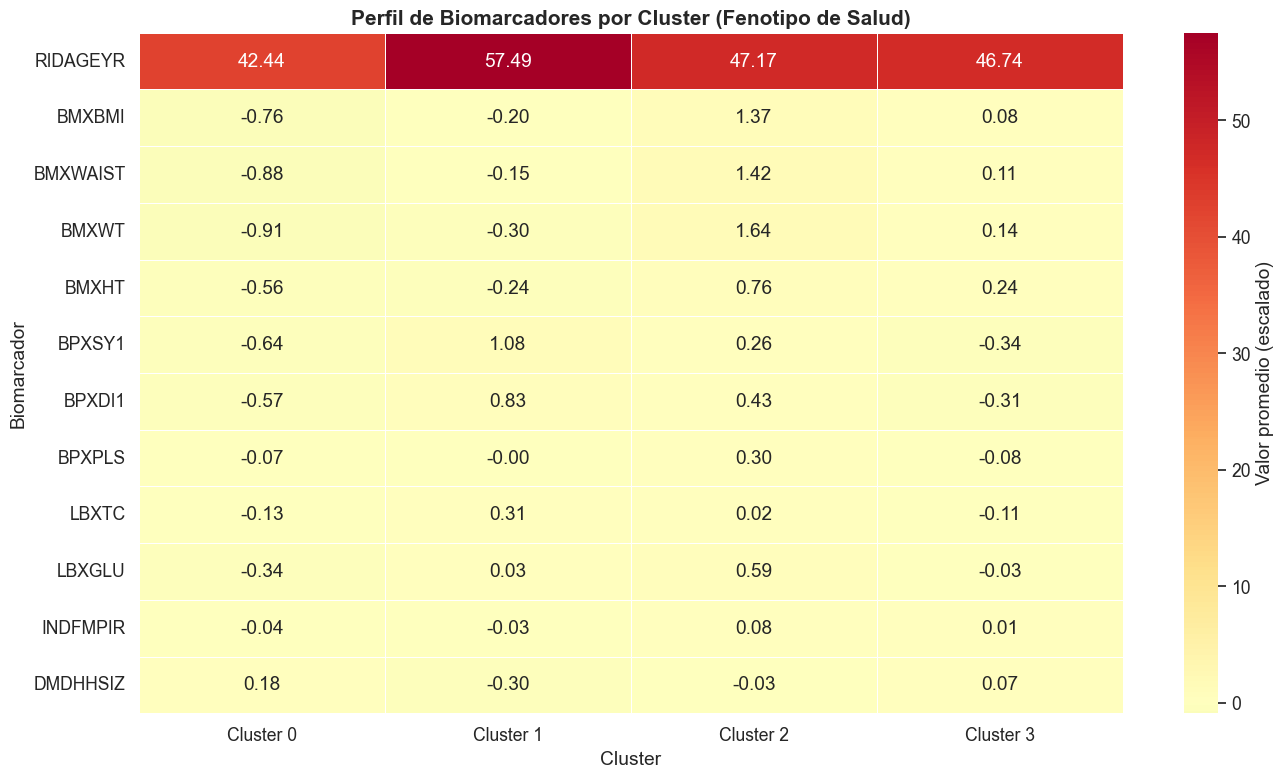

In [15]:
# ── Heatmap de perfiles ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    perfil_clusters.T,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Valor promedio (escalado)'},
    ax=ax
)
ax.set_title('Perfil de Biomarcadores por Cluster (Fenotipo de Salud)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Biomarcador')
plt.tight_layout()
plt.show()

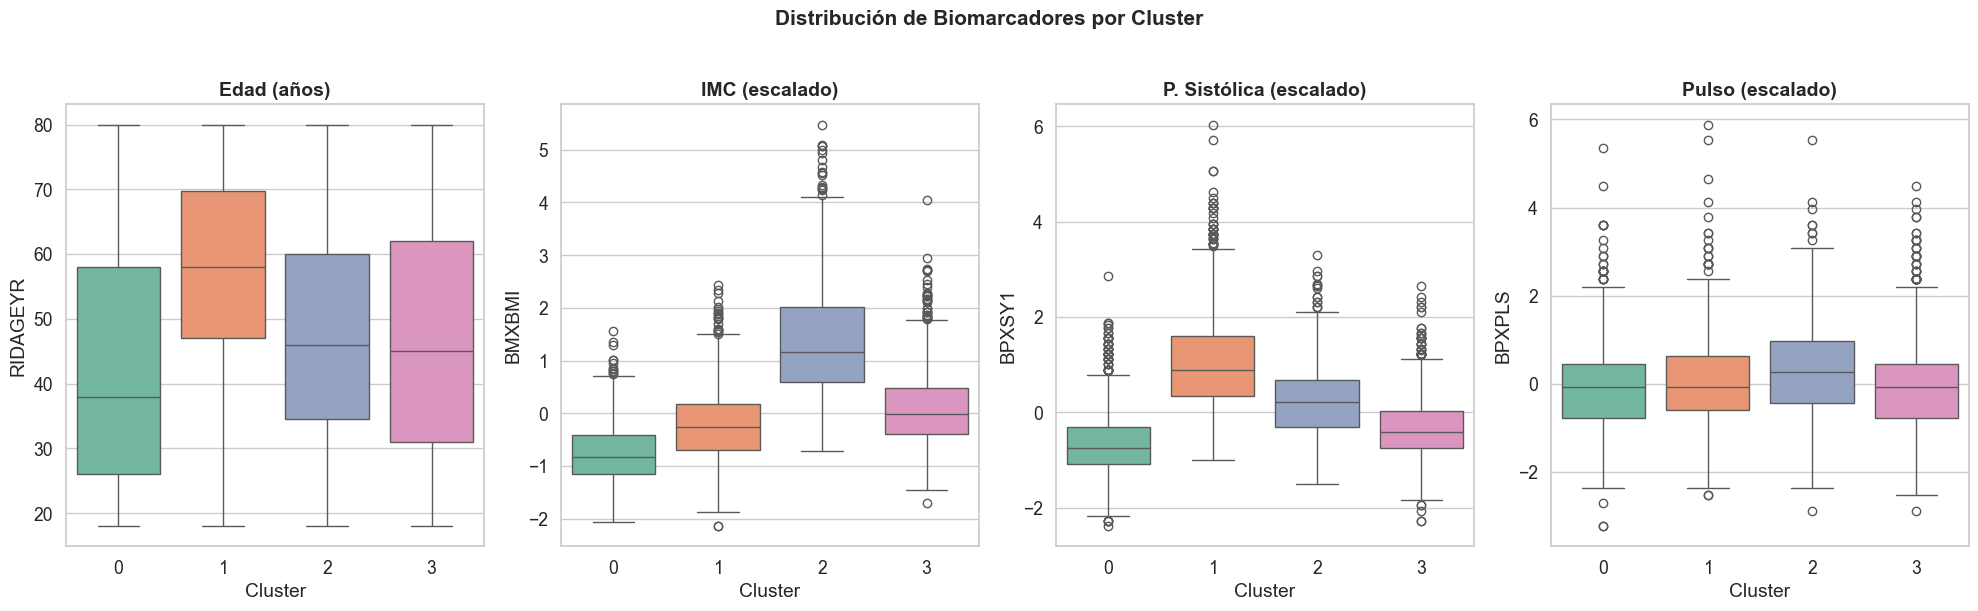

In [16]:
# ── Boxplots comparativos por cluster (variables clave) ────────────────
vars_box = ['RIDAGEYR', 'BMXBMI', 'BPXSY1', 'BPXPLS']
vars_box = [v for v in vars_box if v in df.columns]
titles_box = ['Edad (años)', 'IMC (escalado)', 'P. Sistólica (escalado)', 'Pulso (escalado)']

fig, axes = plt.subplots(1, len(vars_box), figsize=(5 * len(vars_box), 6))

for i, (var, title) in enumerate(zip(vars_box, titles_box)):
    sns.boxplot(data=df, x='CLUSTER', y=var,
                palette=palette_clusters, ax=axes[i])
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Distribución de Biomarcadores por Cluster',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Etiquetado de fenotipos

Basándonos en los perfiles de centroides, asignamos nombres descriptivos a cada cluster.  
Estos nombres son orientativos y deben validarse con el equipo clínico.

In [17]:
# ── Asignación automática de etiquetas basada en edad promedio ──────────
edad_por_cluster = df.groupby('CLUSTER')['RIDAGEYR'].mean().sort_values()

nombres_fenotipos = {
    0: 'Fenotipo A',
    1: 'Fenotipo B',
    2: 'Fenotipo C',
    3: 'Fenotipo D'
}

# Mostrar resumen con contexto
print('🏷️ Fenotipos de Salud Identificados:')
print('=' * 70)
for cluster_id in range(K_FINAL):
    n = (df['CLUSTER'] == cluster_id).sum()
    edad_media = df.loc[df['CLUSTER'] == cluster_id, 'RIDAGEYR'].mean()
    pct_longevo = (df.loc[df['CLUSTER'] == cluster_id, 'IS_LONGEVO'].mean() * 100)
    print(f'\n  Cluster {cluster_id} — {nombres_fenotipos[cluster_id]}:')
    print(f'    Pacientes:     {n:,}')
    print(f'    Edad promedio: {edad_media:.1f} años')
    print(f'    % Longevos:    {pct_longevo:.1f}%')
print('\n' + '=' * 70)
print('\n💡 Nota: Revisa el heatmap de perfiles para interpretar qué biomarcadores')
print('   caracterizan a cada cluster y asignar nombres clínicos más precisos.')

🏷️ Fenotipos de Salud Identificados:

  Cluster 0 — Fenotipo A:
    Pacientes:     1,586
    Edad promedio: 42.4 años
    % Longevos:    13.4%

  Cluster 1 — Fenotipo B:
    Pacientes:     1,366
    Edad promedio: 57.5 años
    % Longevos:    25.0%

  Cluster 2 — Fenotipo C:
    Pacientes:     955
    Edad promedio: 47.2 años
    % Longevos:    9.5%

  Cluster 3 — Fenotipo D:
    Pacientes:     2,085
    Edad promedio: 46.7 años
    % Longevos:    14.7%


💡 Nota: Revisa el heatmap de perfiles para interpretar qué biomarcadores
   caracterizan a cada cluster y asignar nombres clínicos más precisos.


## 8. Conclusiones del Aprendizaje No Supervisado

**Resultados clave:**

1. **PCA:** Los primeros 2 componentes principales capturan una proporción significativa de la varianza total. Las variables de mayor peso son las antropométricas (BMI, cintura) y de presión arterial.
2. **K-Means:** Se identificaron K fenotipos de salud con distintos perfiles metabólicos.
3. **Validación:** El Silhouette Score y el Método del Codo confirman la calidad de la segmentación.
4. **Insight de negocio:** Los clusters muestran una relación con la longevidad — algunos grupos concentran más longevos que otros, validando que los biomarcadores capturan patrones relevantes.

**Siguiente paso:** Notebook 04 — Clasificación supervisada (predecir `IS_LONGEVO`).

---
*Notebook generado como parte del pipeline de Ciencia de Datos EV3 — NHANES 2015-2016*